In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots

import polars as pl
import statsmodels.api as sm
from scipy.stats import norm, t

from datetime import datetime, timedelta
from functools import reduce

# data loader
import sys
sys.path.insert(0, '/Users/zzhu/JupyterLab/MarketMaking/_packages')
from tardis_loader import TardisLoader

import nest_asyncio
nest_asyncio.apply()

from dataclasses import dataclass

In [3953]:
@dataclass
class DataProcessParas:
    # Step 2: Group trades and get the single trade feature we need, depends on the exchanges
    price_round: int = 2, 
    volume_round: int = 4, 
    resample_method: str = 'local_ts',
    latency_gap: int = 5_000, 
    # When handling perps, it could be higher, while dealing with latency cluster, it should be lower. But also need to adjust vol_window and zscore_window correspondly.
    data_span_days: int = 0.5, # Keep the datapoints to be 50-100 (0.5 data_span -> 1 data span) per min. The higher, the more points per min. 50 points seems to be optimal!
    vol_window: int = 100, # 2mins as vol window, don't change
    
    # Step 4: Calculate aggregation features
    feature_windows: list[int] = [15, 30, 60, 90, 150], # Aggregation feature window (better from 0.25min to 2min)
    winsorize_features: list[str] = [], # List of features that require winsorize on total sample
    winsorize_qtl: float = 0.99,
    zscore_window: int = 75,  # Compare current agg feature with the past zscore_window sample, 1.5min is a good looking back window, don't change
    
    # Step 5: Observation Sampling and Set Target Variable
    beta_vol: float = 2,
    fixed_spread: float = 0.5,
    blind_spot_ms: int = 20_000, # Assume we can't use the information happened within 10ms from now
    latency_thres: int = 100_000, # 100ms as latency threshold
    
    # Step 6: Linear Regression
    target: str = 'target_return_normalized'
    lr_features: list[str] = ['buy_vd_z', 'sell_vd_z', 'bcount_z', 'vwap_z'], # Features that used in linear regression
    merge_col: str = 'local_timestamp' # Col that used to merge target df and feature df

#### Functions

**Step 1: Load data from Tardis**

In [ ]:
root_dir = './data'
api_key = 'TD.sSGNjEpohBl9i0FV.zz0-s-b6DZ9c2lt.uoNpgBPGaTITrA9.YlW26JKS0PSfoOG.2pEnnkHAnTpOloD.3wMo'

Tardis_data = TardisLoader(root_dir, api_key)

# Set time and exchanges
start_time = datetime.strptime('2025-03-20', '%Y-%m-%d')
end_time = datetime.strptime('2025-03-26', '%Y-%m-%d')
exchange = 'binance' #'bybit-spot'
symbol = 'btcusdt'
                    
# Load the data
trades_df = Tardis_data.read(start_time, end_time, data_type='trades', exchange=exchange, symbol=symbol)
bbo_df = Tardis_data.read(start_time, end_time, data_type='book_ticker', exchange=exchange, symbol=symbol)
order_book_25 = Tardis_data.read(start_time, end_time, data_type='book_snapshot_25', exchange=exchange, symbol=symbol)
order_book_10 = order_book_25.select(order_book_25.columns[:45])

# Add Latency Column
trades_df, bbo_df, order_book_25, order_book_10 = [
    ds.with_columns([
        (pl.col('local_timestamp') - pl.col('timestamp')).alias('recv_latency'),
        (pl.col('local_timestamp') - pl.col('timestamp')).shift(-1).alias('next_recv_latency')
    ]).filter(pl.col("next_recv_latency").is_not_null())
    for ds in [trades_df, bbo_df, order_book_25, order_book_10]
]

# Take a look at the data
trades_df.describe()

In [ ]:
binance_spot = trades_df

In [ ]:
bybit_perp = trades_df

**Step 2: Plot the col distribution, mostly used for calibrate the mapping parameters**

Usage:
1. "rolling_vwap_std" - map 'vwap_std' to 'spread' via a linear function
2. "target_return_normalized" - map 'target_return' to 'feature_skew' via a arctan function

In [3964]:
def dist_plot(grouped_df: pl.DataFrame, column: str) -> None:
    # Convert the 'price' column to a Pandas Series for plotting
    price_data = grouped_df[column].to_pandas()

    # Plot histogram
    plt.hist(price_data, bins=40, edgecolor='black')  # Adjust bins as needed
    plt.xlabel(column)
    plt.ylabel('Frequency')
    plt.show()

# dist_plot(df, 'rolling_vwap_std')

**Step 3: Group trades and get the single trade feature we need, depends on the exchanges**

**Exchange Details**

1. Bybit: same local timestamp for same bag of trades

In [4006]:
def resample_trades_data(raw_df: pl.DataFrame, hyper_params: DataProcessParas) -> pl.DataFrame():
    '''
    Step 1: Resample the raw transcation data into single trade (depends on the rule of exchanges)
    Step 2: Calculate basic features for each single trade, which will be used in aggregation features later
    Step 3: Filter significant trades by volume - to make sure that we always have aroud 100 valid data point per minute
    
    Single Trade Feature: 'vwap', 'volume', 'initial_price'
    Regime Feature (after filter): 'vwap_diff', 'vwap_diff_square'
    '''
    # Access to hyperparameters
    price_round = hyper_params.price_round
    volume_round = hyper_params.volume_round
    resample_method = hyper_params.resample_method
    latency_gap = hyper_params.latency_gap
    
    # Feature of single trade (volume, vwap)
    if resample_method == 'local_ts':
        grouped_trades = raw_df.group_by("local_timestamp").agg(
            pl.col("human_time").first(),
            pl.col("timestamp").first().alias("exch_time"),
            pl.col("recv_latency").first(),
            pl.col("price").first().alias("initial_price"),
            pl.col("side").first(),
            ((pl.col("price") * pl.col("amount")).sum() / pl.col("amount").sum()).alias("vwap"),
            pl.col("amount").sum().alias("volume"),
        ).with_columns(
            pl.col('local_timestamp').alias('bucket_id')
        )
    elif resample_method == 'latency':
        grouped_trades = raw_df.with_columns(
            pl.when(pl.col('timestamp').diff() > latency_gap).then(pl.lit(1)).otherwise(0).cum_sum().fill_null(0).alias('bucket_id')
        ).group_by("bucket_id").agg(
            pl.col("local_timestamp").first(),
            pl.col("human_time").first(),
            pl.col("timestamp").first().alias("exch_time"),
            pl.col("recv_latency").first(),
            pl.col("price").first().alias("initial_price"),
            pl.col("side").first(),
            ((pl.col("price") * pl.col("amount")).sum() / pl.col("amount").sum()).alias("vwap"),
            pl.col("amount").sum().alias("volume"),
        )
    else:
        raise AttributeError('Not supported resample method')
        
    # Round digit for specific columns
    grouped_trades = grouped_trades.with_columns(
        pl.col('vwap').round(price_round).alias('vwap'),
        pl.col('volume').round(volume_round).alias('volume')
    ).sort('bucket_id')
        
    return grouped_trades

In [4008]:
def filter_trades_data(grouped_df: pl.DataFrame, hyper_params: DataProcessParas) -> pl.DataFrame:
    # Access to hyperparameter
    data_span_days = hyper_params.data_span_days
    vol_window = hyper_params.vol_window
    
    # Choose the volume threshold to make that we can have 100 valid trade per minute on average
    min_sample_ratio = (data_span_days * 1440 * 100) / grouped_df.shape[0] # baseline - 100 trades per minute
    volume_threshold = grouped_df.select(pl.col("volume").quantile(1 - min_sample_ratio)).to_numpy()[0][0]
    print(f'volume_threshold: {volume_threshold}')
    
    # Feature of vwap diff between filtered data points - Used for vol calculation
    filtered_trades = grouped_df.filter(
        pl.col("volume") >= volume_threshold
    ).with_columns(
        (((pl.col('vwap').diff())/pl.col('vwap')*10000)).alias('vwap_diff'),
        (((pl.col('vwap').diff())/pl.col('vwap')*10000).pow(2)).alias('vwap_diff_square'),
    ).drop_nulls().with_row_index().with_columns(
        pl.mean("vwap_diff_square").rolling(index_column="index", period=f"{vol_window}i").pow(0.5).alias(f'rolling_vwap_std')
    )
    
    return filtered_trades

**Step 4: Calculate aggregation features**

In [3972]:
def agg_feature(filtered_df: pl.DataFrame, hyper_params: DataProcessParas, feature_window: int) -> pl.DataFrame:
    '''
    Calculate the aggregation features and drop outliers via winsorize
    
    Features: "vwap_diff_sum", "buy_count_ratio", "vwap"
    
    Features that need to be winsorized: ""
    '''
    # Access to hyperparamters
    winsorize_features = hyper_params.winsorize_features
    winsorize_qtl = hyper_params.winsorize_qtl
    
    # Keep the local_timestap as the common column to merge with valid dp in future process
    agg_feature_df = filtered_df.rolling(index_column="index", period=f"{feature_window}i").agg(
        pl.col('local_timestamp').first(),
        pl.col('vwap_diff').filter(pl.col('side') == 'buy').sum().alias('buy_vwap_diff_sum'),
        (pl.col('vwap_diff').filter(pl.col('side') == 'sell').sum() * -1).alias('sell_vwap_diff_sum'),
        (pl.col('side').filter(pl.col('side') == 'buy').count() / feature_window).alias('buy_count_ratio'),
        (pl.col('volume').filter(pl.col('side') == 'buy').sum() / pl.col('volume').sum()).alias('buy_volume_ratio'),
        pl.col('vwap').last().alias('vwap')
    )
    
    # Drop data in the warm-up period
    agg_feature_df = agg_feature_df[feature_window:].fill_nan(0)
    
    # Drop outliers via winsorize over entire sample
    for feature in winsorize_features:
        up_limit = agg_feature_df[feature].quantile(winsorize_qtl)
        agg_feature_df = agg_feature_df.with_columns(
            pl.when(pl.col(feature) >= up_limit).then(up_limit).otherwise(pl.col(feature)).alias(feature),
        )    
    
    return agg_feature_df
    

In [3974]:
def rolling_zscore(agg_df: pl.DataFrame, hyper_params: DataProcessParas) -> pl.DataFrame:
    '''
    Calculate the rolling z-score of features.
    
    Default: All features will be replaced by their rolling z-score
    '''
    # Access to hyperparamters
    zscore_window = hyper_params.zscore_window
    
    zscore_df = agg_df.rolling(index_column="index", period=f"{zscore_window}i").agg(
        pl.col('local_timestamp').first(),
        ((pl.col('buy_vwap_diff_sum').last() - pl.col('buy_vwap_diff_sum').mean()) / pl.col('buy_vwap_diff_sum').std()).alias('buy_vd_z'),
        ((pl.col('sell_vwap_diff_sum').last() - pl.col('sell_vwap_diff_sum').mean()) / pl.col('sell_vwap_diff_sum').std()).alias('sell_vd_z'),
        ((pl.col('buy_count_ratio').last() - pl.col('buy_count_ratio').mean()) / pl.col('buy_count_ratio').std()).alias('bcount_z'),
        ((pl.col('buy_volume_ratio').last() - pl.col('buy_volume_ratio').mean()) / pl.col('buy_volume_ratio').std()).alias('bvolume_z'),
        ((pl.col('vwap').last() - pl.col('vwap').mean()) / pl.col('vwap').std()).alias('vwap_z'),
    )
    
    # Drop data in the warm-up period
    zscore_df = zscore_df[zscore_window:].fill_nan(0)
    
    return zscore_df

**Step 5: Observation Sampling and Set Target Variable**

In [4097]:
def ob_stv(grouped_df: pl.DataFrame, hyper_params: DataProcessParas, offset: int = -10_000_000) -> pl.DataFrame:
    '''
    Step 1: Filtering the samples that we care (where we more likely to trade)
    
    Step 2: Set a apropriate target variable - vwap diff between current significant trade and next opposite significant trade 
    
    Step 3: Normalize the target variable with rolling vwap std (which is also required by production)
    
    Step 4: Filter out high latency data points
    '''
    # Access to hyperparamters
    beta_vol = hyper_params.beta_vol
    fixed_spread = hyper_params.fixed_spread
    blind_spot_ms = hyper_params.blind_spot_ms
    latency_thres = hyper_params.latency_thres
    
    # Step 1: Valid vwap diff should meet such condition: last trade should be the most recent one happened at least 10ms before
    target_df = grouped_df.with_columns(
        pl.last("vwap").rolling(index_column="exch_time", offset=f'{offset}i', period=f'{-blind_spot_ms-offset}i').alias(f'rolling_{int(blind_spot_ms/1000)}ms_vwap')
    ).drop_nulls().with_columns(
        ((pl.col('vwap') - pl.col(f'rolling_{int(blind_spot_ms/1000)}ms_vwap')) / pl.col('vwap') * 10_000).alias('valid_vwap_diff')
    )
    
    # It's more accurate to calculate the valid vwap diff before volume filtering!
    target_df = filter_trades_data(target_df, hyper_params)
    
    # Step 2.1: Calculate the spread we will set in production, to filter the significant trade we most care about
    target_df = target_df.with_columns(
        (pl.col("rolling_vwap_std") * beta_vol + fixed_spread).alias('prod_spread')
    ).filter(
        (pl.col('valid_vwap_diff').abs() >= pl.col('prod_spread'))
    )
        
    # Step 2.2: Calculate the target varible: current_vawp - next_opposite_trade_vwap
    target_df = target_df.with_columns(
        (pl.when(pl.col('side') == 'sell').then(pl.lit(0)).otherwise(pl.lit(1)).diff().abs().cum_sum().fill_null(0)).alias('bucket_id')
    )
    
    # Step 2.3: Get the next opposite trade vwap
    target_df_2 = target_df.select(
        (pl.col('bucket_id') - 1).alias('bucket_id'),
        pl.col('vwap').alias('vwap')
    ).group_by('bucket_id').agg(
        pl.col('vwap').first().alias('next_trade_price')
    )
    
    # Step 2.4: Merge it back to original df, then we can get our target variable
    target_df = target_df.join(target_df_2, on='bucket_id', how='left').drop_nulls().with_columns(
        ((pl.col('vwap') - pl.col('next_trade_price')) / pl.col('vwap') * 10000).alias('target_return_bps')
    )
    
    # Step 3: Normalize target variable with rolling vwap std
    target_df = target_df.with_columns(
        (pl.col('target_return_bps') / pl.col('rolling_vwap_std')).alias('target_return_normalized')
    )
    
    # Step 4: Final filter - filter out repetition samples which are too close to each other and high latency samples
    target_df = target_df.filter(
        pl.col('exch_time').diff() >= blind_spot_ms,
        pl.col('recv_latency') <= latency_thres
    )
    
    return target_df

**Step 6: Linear Regression**

In [4037]:
def linreg(target_df: pl.DataFrame, feature_df: pl.DataFrame, hyper_params: DataProcessParas) -> None:
    '''
    Run the linear regression
    '''
    # Access to hyperparamters
    target = hyper_params.target
    feature_list = hyper_params.lr_features
    merge_col = hyper_params.merge_col
    
    lr_df = target_df.select(
        pl.col(merge_col),
        pl.col(target)
    ).join(feature_df, on=merge_col, how='inner').drop_nulls()
    
    df = lr_df.to_pandas()

    # Define the feature columns and the target column
    X = df[feature_list]  # Feature columns
    y = df[target]  # Target column

    # Add a constant column (intercept) to the feature columns for statsmodels
    X = sm.add_constant(X)

    # Run regression and print result
    model = sm.OLS(y, X).fit()
    print(model.summary())
    
    return lr_df

#### Regression Test - 1

In [4181]:
hyper_paras = DataProcessParas(
    # Step 2: Group trades and get the single trade feature we need, depends on the exchanges
    price_round = 2,
    volume_round = 4,
    resample_method = 'local_ts',
    latency_gap = 5_000,
    # When handling perps, it could be higher, while dealing with latency cluster, it should be lower. But also need to adjust vol_window and zscore_window correspondly.
    data_span_days = 3.5, # Keep the datapoints to be 50-100 (0.5 data_span -> 1 data span) per min. The higher, the more points per min. 50 points seems to be optimal!
    vol_window = 100, # 2mins as vol window, don't change
    
    # Step 4: Calculate aggregation features
    feature_windows = [15, 30, 60, 90, 150], # agg feature window, can consider use average of different window value
    winsorize_features = [],
    winsorize_qtl = 0.99,
    zscore_window = 75, # Compare current agg feature with the past zscore_window sample, seems 150 is a good number, don't change. (i.e. 1.5min)
    
    # Step 5: Observation Sampling and Set Target Variable
    beta_vol = 1,
    fixed_spread = 0.25,
    blind_spot_ms = 20_000,
    latency_thres = 100_000,
    
    # Step 6: Linear Regression
    target = 'target_return_normalized',
    lr_features = ['buy_vd_z', 'sell_vd_z', 'bcount_z', 'bvolume_z', 'vwap_z'], #['buy_vd_z', , , , ],
    merge_col = 'local_timestamp'
)

volume_threshold: 0.128


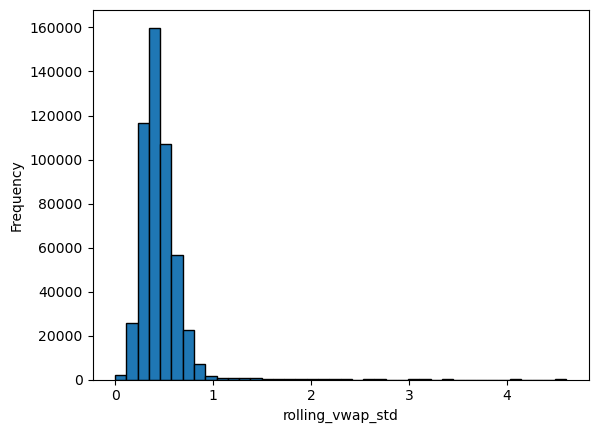

In [4183]:
grouped_df = resample_trades_data(bybit_perp, hyper_paras)
filtered_df = filter_trades_data(grouped_df, hyper_paras)
dist_plot(filtered_df, 'rolling_vwap_std')

In [4184]:
avg_zscore_df = pl.DataFrame()
for feature_window in hyper_paras.feature_windows:
    feature_df = agg_feature(filtered_df, hyper_paras, feature_window)
    zscore_df = rolling_zscore(feature_df, hyper_paras)
    
    zscore_df = zscore_df.drop('index')

    if avg_zscore_df.height == 0:
        avg_zscore_df = zscore_df
    else:
        df_joined = avg_zscore_df.join(zscore_df, on="local_timestamp", how="inner", suffix="_df2")
        avg_zscore_df = df_joined.select(
            pl.col("local_timestamp"),
            *[(pl.col(col) + pl.col(f"{col}_df2")).alias(col) for col in avg_zscore_df.columns if col != "local_timestamp"]
        )
        
# Divided by feature windows length
avg_zscore_df = avg_zscore_df.select(
    pl.col("local_timestamp").alias("local_timestamp"),
    *[pl.col(col) / len(hyper_paras.feature_windows) for col in avg_zscore_df.columns if col != "local_timestamp"]
)

# # Doing clipping
# for feature in zscore_df.columns:
#     if feature == 'local_timestamp':
#         continue
#     upper_limit = 3
#     lower_limit = -3
#     avg_zscore_df = avg_zscore_df.with_columns(
#         pl.when(pl.col(feature) >= upper_limit).then(upper_limit)
#         .when(pl.col(feature) <= lower_limit).then(lower_limit)
#         .otherwise(pl.col(feature)).alias(feature),
#     )

prev_length = avg_zscore_df.height

# Doing droping
for feature in zscore_df.columns:
    if feature == 'local_timestamp':
        continue
    upper_limit = 10
    lower_limit = -10
    avg_zscore_df = avg_zscore_df.filter(
        pl.col(feature) <= upper_limit,
        pl.col(feature) >= lower_limit
    )

drop_nums = prev_length - avg_zscore_df.height
print(f'drop {drop_nums} outliers out of {prev_length} samples')

drop 1505 outliers out of 503808 samples


volume_threshold: 0.128


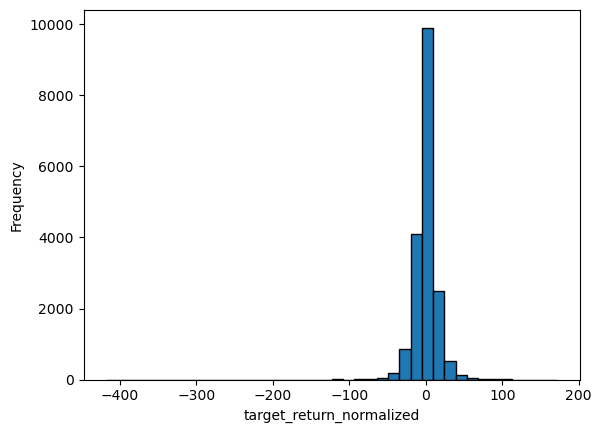

In [4185]:
target_df = ob_stv(grouped_df, hyper_paras)
dist_plot(target_df, hyper_paras.target)

In [4186]:
lr_df = linreg(target_df, avg_zscore_df, hyper_paras)

                               OLS Regression Results                               
Dep. Variable:     target_return_normalized   R-squared:                       0.188
Model:                                  OLS   Adj. R-squared:                  0.188
Method:                       Least Squares   F-statistic:                     848.3
Date:                      Mon, 07 Apr 2025   Prob (F-statistic):               0.00
Time:                              17:31:04   Log-Likelihood:                -73379.
No. Observations:                     18350   AIC:                         1.468e+05
Df Residuals:                         18344   BIC:                         1.468e+05
Df Model:                                 5                                         
Covariance Type:                  nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------

#### Download raw data for specific time period

In [ ]:
time = 1742429049008000
btc_trades.collect().filter(pl.col('timestamp') >= time)[:1000].to_pandas().to_csv(f'{time}_btc_trades_sample.csv')
btc_ob.collect().filter(pl.col('timestamp') >= time)[:1000].to_pandas().to_csv(f'{time}_btc_ob_sample.csv')
btc_bbo.collect().filter(pl.col('timestamp') >= time)[:1000].to_pandas().to_csv(f'{time}_btc_bbo_sample.csv')

In [426]:
btc_trades_bn.collect().filter(pl.col('timestamp') >= time)[:1000].to_pandas().to_csv(f'{1742429045008000}_btc_trades_sample.csv')